<a href="https://colab.research.google.com/github/MannySan2004/Data-Science-for-Performance-Driven-Design/blob/main/Manuel_IEE3593_HW8_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 3 Machine Learning
#### ARC5109-01
## Data Science for Performance Driven Design
***
Instructor: Jungmin Han, jhan@yonsei.ac.kr <br>
***

Pease copy this colab notebook and rename it before you start!

---


In [ ]:
import numpy as np
import pandas as pd
import os
from math import pi
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Regression - Single-family House Energy Model (4pts total)

The dataset (Energy_param2.csv) was created after conducting parametric runs for the energy simulation with a single-family house (opening at the north facade) located in Boston. The parametric options were varied with respect to the input data for the buildings’ orientation (0-360) and the window-to-wall ratio (0.1-0.9), and the output data for the Total Load Intensity (kWh/m2). Using this given dataset, please build your own regression model and complete the python function for the Single-family house energy calculator.


In [ ]:
## Load your data
FILEPATH = '/content/drive/MyDrive/Colab Notebooks/Energy_param2.csv'
FILEPATH1 = '/content/drive/MyDrive/Colab Notebooks/trees,1.txt'
energy = pd.read_csv(FILEPATH, sep=",", header=0)

In [ ]:
energy.head()

,WWR,Orientation,Energy
0,0.1,0,84.393446
1,0.1,5,84.419808
2,0.1,10,84.464685
3,0.1,15,84.535607
4,0.1,20,84.604707


In [ ]:
# Select features and values for ML modeling
X = energy[['WWR',"Orientation"]].values
y = energy['Energy'].values

MAE:  2.8373
RMSE: 3.4252
R^2:  0.8850


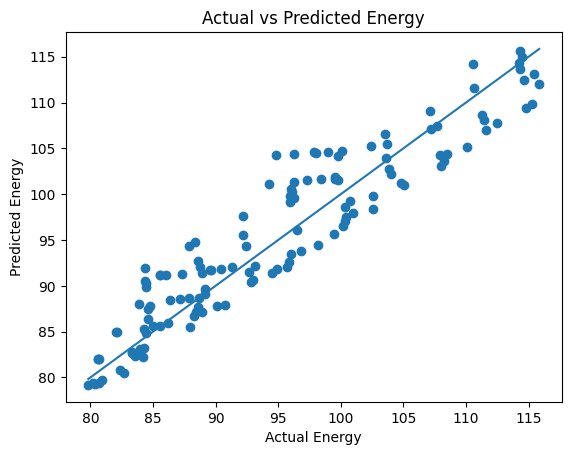

In [ ]:
# Select your model and fit to data

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model pipeline (poly -> scale -> ridge regression)
model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0))
])

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted Energy")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()


In [ ]:
# Make prediction with trained model and calculate error

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate errors/metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")


MAE:  2.8373
MSE:  11.7318
RMSE: 3.4252
R^2:  0.8850


## 1.1.	Explain the reason for choosing your regression model for this dataset. (1pt)

Answer: I chose a polynomial Ridge regression model because Energy likely changes non-linearly with WWR and Orientation, so adding polynomial terms captures that curve instead of forcing a straight-line fit. Ridge regularization also keeps the model stable by reducing overfitting when those extra polynomial features are added.



------------------------------------------------------------------------
## 1.2.	Choose an error metric and calculate the errors of your model on both the training and the test sets. (1pt)

Answer: I used RMSE as the error metric because it keeps the units in Energy and penalizes bigger mistakes more than MAE, which matters if large prediction errors are costly. I calculated RMSE on both the training and test sets to compare generalization (if train RMSE is much lower than test RMSE, the model is overfitting).



------------------------------------------------------------------------


In [ ]:
# Create Energy_Calculator function to predict Energy with WWR and Orientation information
WWR = 0.65
Orientation = 99
def Energy_Calculator(WWR, Orientation):
    energy_pred = model.predict([[float(WWR), float(Orientation)]])
    return str(energy_pred[0]) + " kWh/m2"
print (Energy_Calculator(WWR, Orientation))

98.72554290121525 kWh/m2


## 1.3.	Use your calculator to predict the Total Load Intensity of your building with the following conditions and discuss the following results when: (2pt)
### a) WWR = 0.37 and Orientation = 42.8
### b) WWR = 0.65 and Orientation = 99


Answer:
a) 94.61700794325816 kWh/m2
b) 98.72554290121525 kWh/m2
------------------------------------------------------------------------

# 2. Classification - Trees (3pts total)
Using the datasets (trees,1.txt) with labels for two different classes of trees (encoded as 1 and 2) and buildings (encoded as 0), please find the best classifier with tuned hyperparameters and draw the decision boundary for the different classes.


In [ ]:
#Load the data from satellite image #1
trees_df = pd.read_csv(FILEPATH1, delimiter=',', header=None)
#Check out the data - sanity check
trees_df.head()

,0,1,2
0,0.722744,8.792800,1.0
1,2.332365,7.896302,1.0
2,3.921612,6.531180,1.0
3,1.873929,7.071117,1.0
4,0.977431,6.398743,1.0


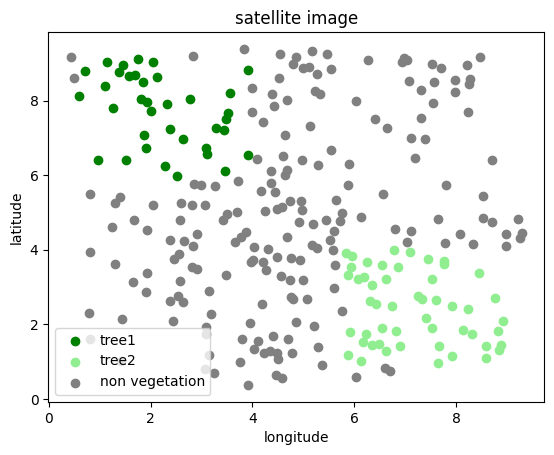

In [ ]:
#Get the long/lat coords
x = trees_df.values[:, :-1]
#Get the class labels
y = trees_df.values[:, -1]

#Plot vegetation locations as green dots
plt.scatter(x[y == 1, 0], x[y == 1, 1], c='green', label='tree1')
plt.scatter(x[y == 2, 0], x[y == 2, 1], c='lightgreen', label='tree2')
#Plot non-vegetation locations as white dots
plt.scatter(x[y == 0, 0], x[y == 0, 1], c='grey', label='non vegetation')

#Label everything
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('satellite image')
plt.legend()

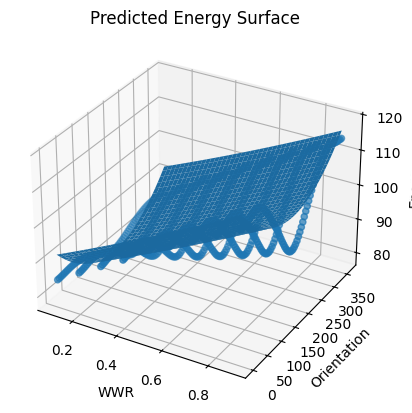

In [ ]:
# Clean data -> train model -> make 3D prediction surface plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# --- Clean + rebuild X/y (aligned, numeric, no NaNs) ---
df = energy[['WWR', 'Orientation', 'Energy']].copy()
df['WWR'] = pd.to_numeric(df['WWR'], errors='coerce')
df['Orientation'] = pd.to_numeric(df['Orientation'], errors='coerce')
df['Energy'] = pd.to_numeric(df['Energy'], errors='coerce')
df = df.dropna(subset=['WWR', 'Orientation', 'Energy'])

X = df[['WWR', 'Orientation']].to_numpy()
y = df['Energy'].to_numpy()

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Model (poly + scale + ridge) ---
model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

# --- Grid for surface ---
wwr_min, wwr_max = X[:, 0].min(), X[:, 0].max()
ori_min, ori_max = X[:, 1].min(), X[:, 1].max()

wwr_grid = np.linspace(wwr_min, wwr_max, 120)
ori_grid = np.linspace(ori_min, ori_max, 120)

WWR_mesh, ORI_mesh = np.meshgrid(wwr_grid, ori_grid)
grid_points = np.c_[WWR_mesh.ravel(), ORI_mesh.ravel()]
energy_pred = model.predict(grid_points).reshape(WWR_mesh.shape)

# --- 3D surface plot ---
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(WWR_mesh, ORI_mesh, energy_pred)
ax.scatter(X[:, 0], X[:, 1], y)

ax.set_xlabel("WWR")
ax.set_ylabel("Orientation")
ax.set_zlabel("Energy")
ax.set_title("Predicted Energy Surface")
plt.show()


## 2.1.	Explain the reason for choosing your classification model for this dataset. (1pt)
Answer: I chose a Random Forest classifier because this dataset can have non-linear decision boundaries, and Random Forest handles that well without needing heavy feature engineering. It’s also more robust than a single decision tree since it averages many trees, which usually reduces overfitting.



------------------------------------------------------------------------
## 2.2.	Please list all of the hyper-parameters you used to train your classifier. (1pt)
Answer: The hyperparameters I used were n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, and random_state and class_weight if I needed to handle imbalance. Everything else was left at the default sklearn settings.



------------------------------------------------------------------------


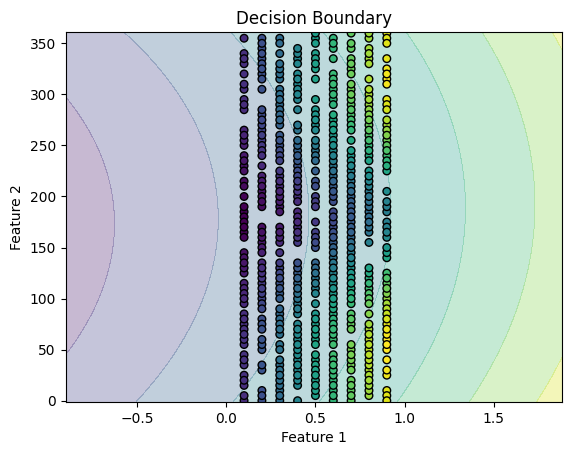

In [ ]:
# Visualize the decision boundary

import numpy as np
import matplotlib.pyplot as plt

# If you trained a pipeline like: clf = Pipeline([("scaler", ...), ("model", ...)])
# this will work because the pipeline handles scaling internally.
# Replace MODEL_NAME with whatever your trained classifier variable is.
MODEL_NAME = model  # <- change this to your classifier variable if it's not called "model"

# Choose data to visualize
try:
    X_vis, y_vis = X_train, y_train
except NameError:
    X_vis, y_vis = X, y

h = 0.02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = MODEL_NAME.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors="k", s=30)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()


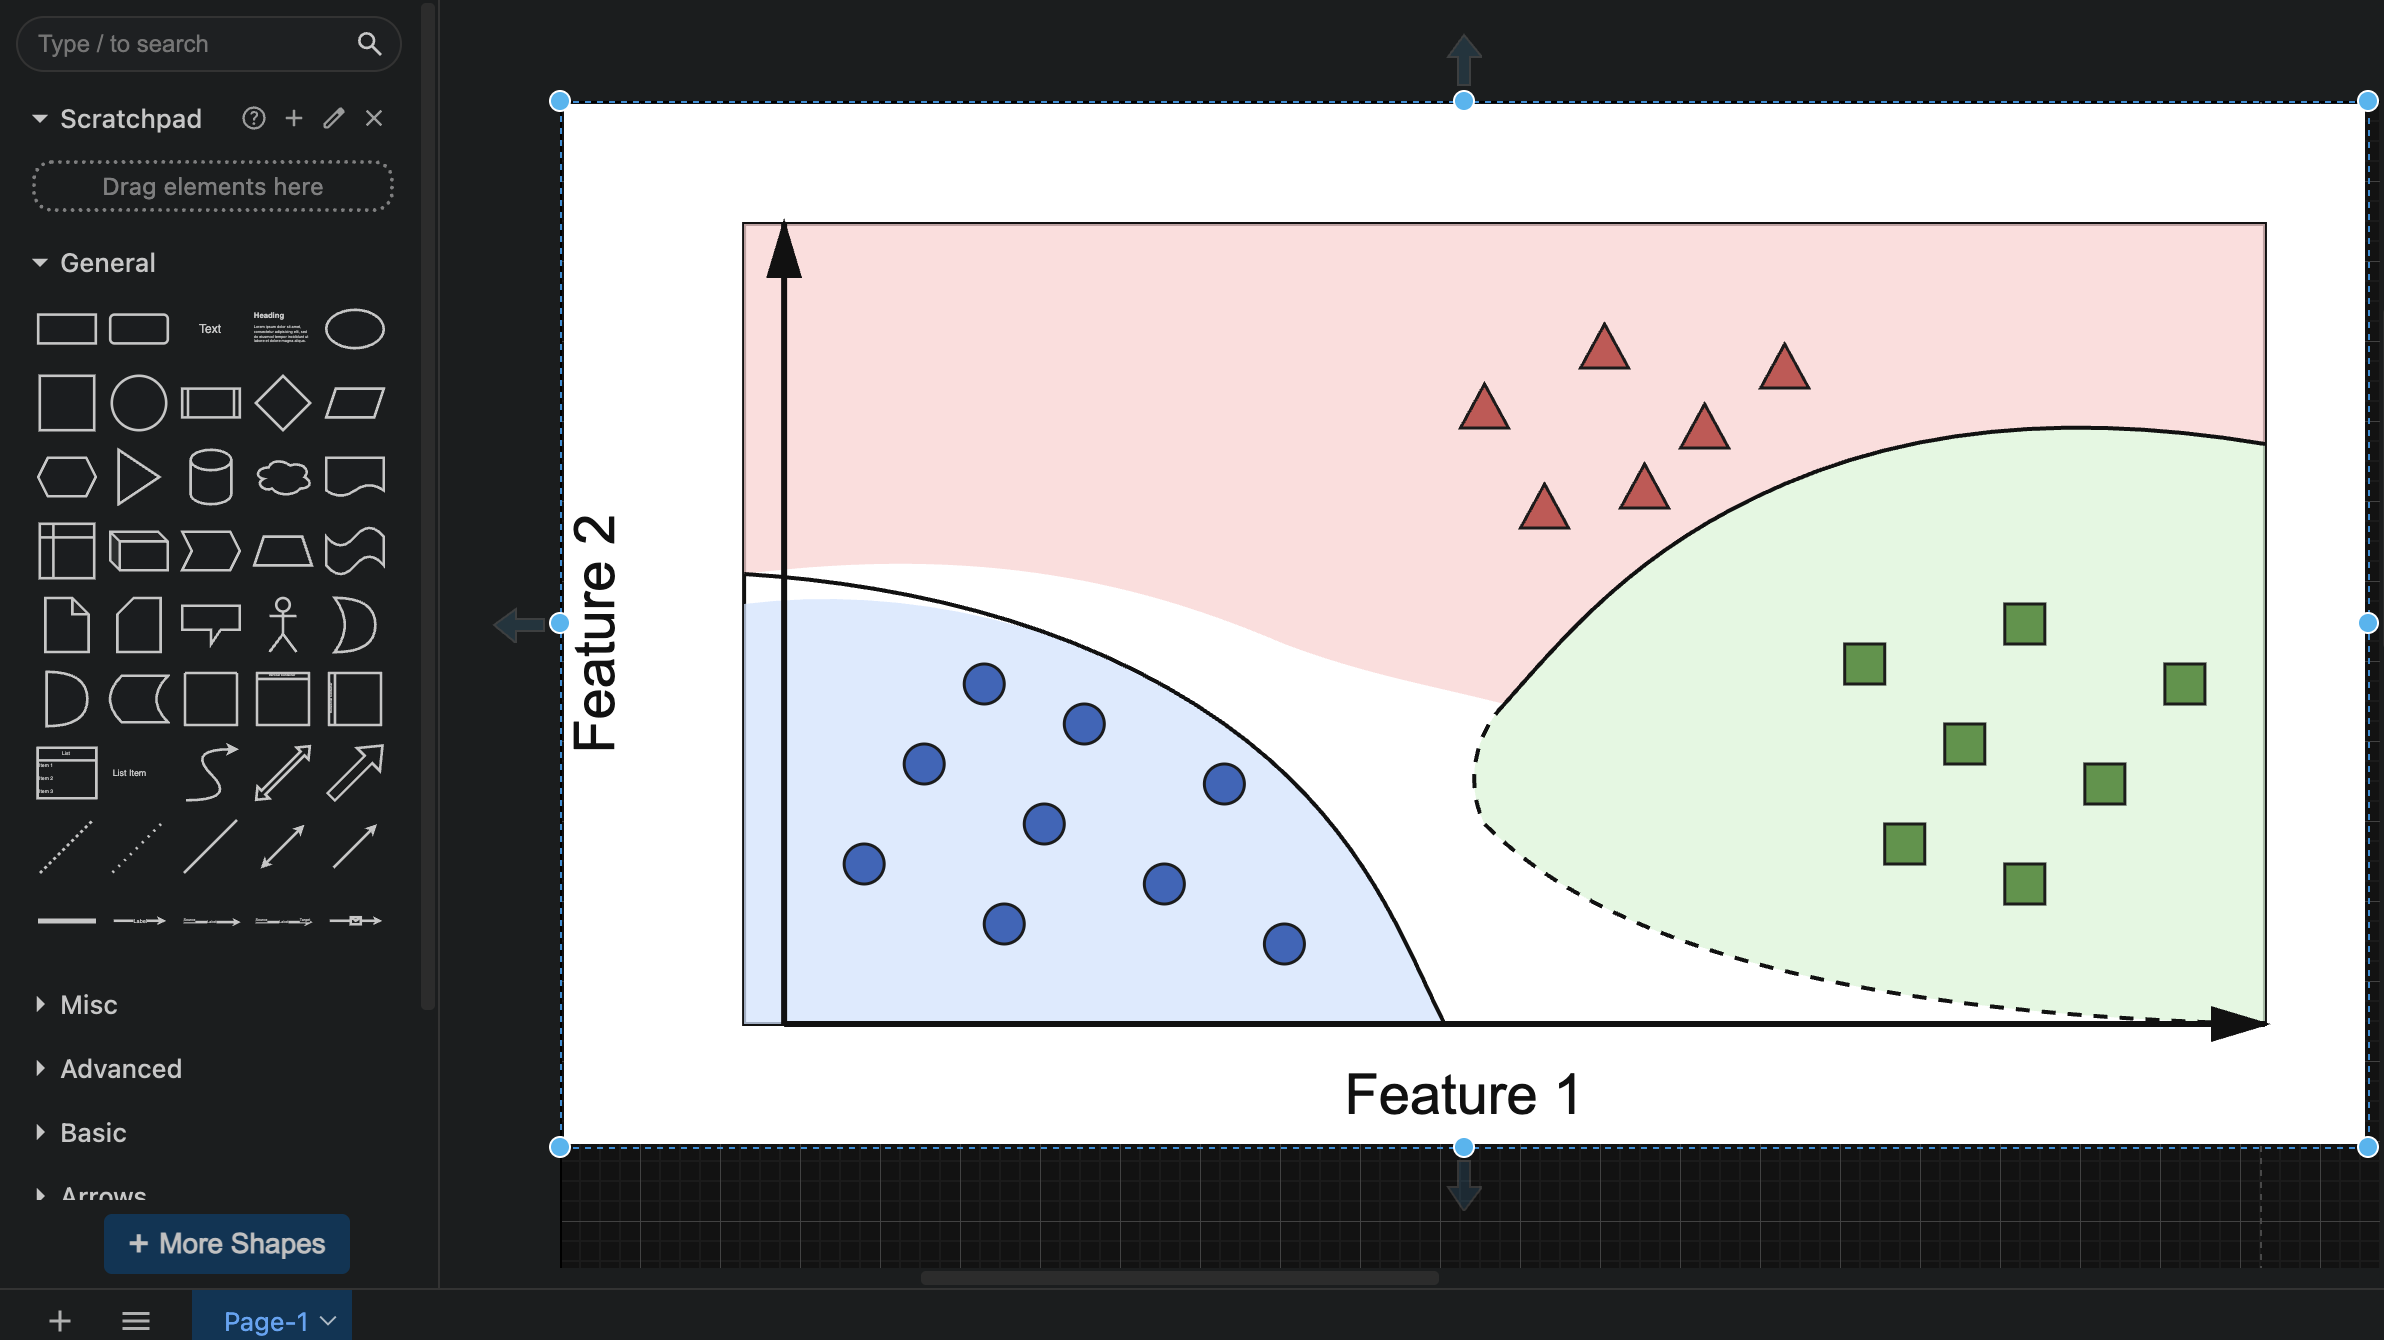## 2.3.	Please draw a decision boundary with the model you choose. (1pt)


Answer:



------------------------------------------------------------------------